# Validación del modelo de zonas calientes

Como el dataset es **sintético**, conocemos la verdad: los **centros reales** de cada zona,
qué celdas son **realmente calientes** (`is_hot_true`) y a qué zona pertenece cada una
(`zone_id_true`). Eso permite medir qué tan bien la salida del modelo recupera esa verdad.

> El modelo es **no supervisado**: el ground-truth se usa SOLO para medir en este notebook,
> nunca como entrada del clustering.

Validamos cinco cosas:
- **A. Recuperación espacial** — ¿las zonas predichas caen sobre los centros reales?
- **B. Detección** — precision / recall de celdas calientes vs `is_hot_true`.
- **C. Concordancia** — ARI / NMI de los clusters vs las zonas reales (`zone_id_true`).
- **D. Coherencia temporal** — la demanda capturada sigue el patrón horario plantado.
- **E. Generalización** — con otra semilla (datos nuevos) sigue funcionando.

In [1]:
# Bootstrap: ubica la raíz del repo (funciona desde notebooks/ o desde la raíz)
import sys, os
from pathlib import Path
_raiz = Path.cwd()
while not (_raiz / "app").exists() and _raiz != _raiz.parent:
    _raiz = _raiz.parent
os.chdir(_raiz)
if str(_raiz) not in sys.path:
    sys.path.insert(0, str(_raiz))
print("raíz:", _raiz)

raíz: C:\Users\eduar\Desktop\Universidad\9VO CUATRI\Integrador\ZonasCalientes-ML


In [2]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from generate_synthetic import cargar_config, generar_nivel_a, agregar_nivel_b
from app.infrastructure.data.demanda import cargar_demanda
from app.infrastructure.ml.dbscan import clusterizar_demanda
from training import validar as V

cfg = cargar_config(V.CONFIG_PATH)
df_b = cargar_demanda()
centros = V.centros_reales(cfg)
FIG = "figures"
print(f"Nivel B: {len(df_b)} celdas | municipios: {sorted(df_b.municipio.unique())}")
print("Centros reales por municipio:", {m: len(c) for m, c in centros.items()})

Nivel B: 5357 celdas | municipios: [np.int64(1), np.int64(2)]
Centros reales por municipio: {1: 3, 2: 2}


## A. Recuperación espacial

Para cada **zona predicha** medimos la distancia (haversine) al **centro real** más cercano
de su municipio. Si el modelo funciona, las zonas deberían caer sobre los centros plantados.

In [3]:
rec = V.recuperacion_espacial(df_b, centros)
print(f"Zonas predichas (todos los buckets): {len(rec)}")
display(rec["dist_centro_real_m"].describe().round(1).to_frame("dist_al_centro_real_m"))
print("Dentro de 150 m (½ celda):", round((rec.dist_centro_real_m <= 150).mean()*100, 1), "%")
print("Dentro de 300 m (1 celda):", round((rec.dist_centro_real_m <= 300).mean()*100, 1), "%")

Zonas predichas (todos los buckets): 240


,dist_al_centro_real_m
count,240.0
mean,24.1
std,21.3
min,0.6
25%,10.8
50%,15.7
75%,28.4
max,134.5


Dentro de 150 m (½ celda): 100.0 %
Dentro de 300 m (1 celda): 100.0 %


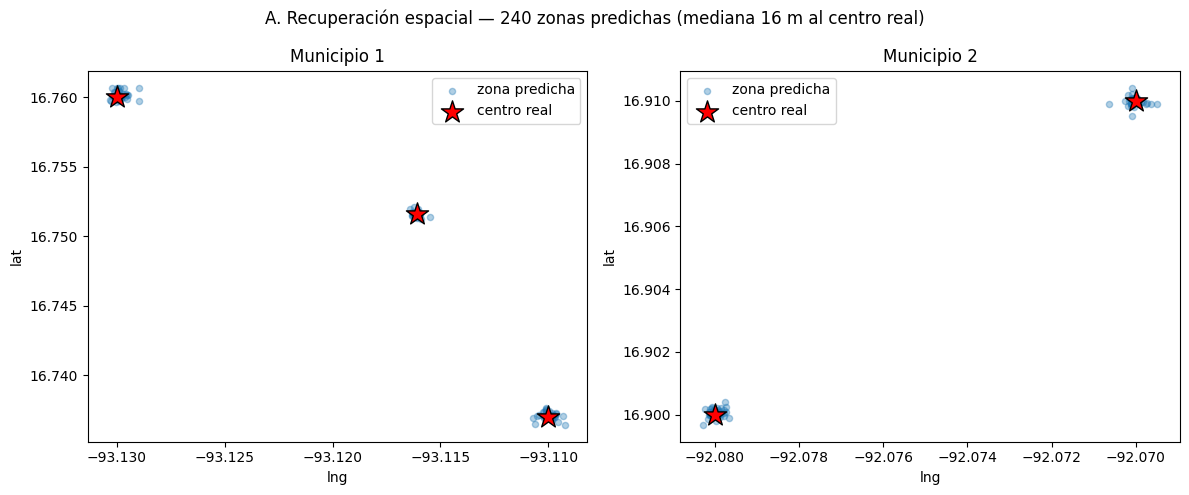

In [4]:
fig, axes = plt.subplots(1, len(centros), figsize=(12, 5))
for ax, muni in zip(np.atleast_1d(axes), sorted(centros)):
    z = rec[rec.municipio == muni]
    ax.scatter(z.lng, z.lat, s=20, c="tab:blue", alpha=0.35, label="zona predicha")
    cs = centros[muni]
    ax.scatter(cs[:, 1], cs[:, 0], s=280, marker="*", c="red", edgecolor="k", zorder=5, label="centro real")
    ax.set_title(f"Municipio {muni}"); ax.set_xlabel("lng"); ax.set_ylabel("lat"); ax.legend()
fig.suptitle(f"A. Recuperación espacial — {len(rec)} zonas predichas "
             f"(mediana {rec.dist_centro_real_m.median():.0f} m al centro real)")
fig.tight_layout(); fig.savefig(f"{FIG}/val_mapa_recuperacion.png", dpi=120); plt.show()

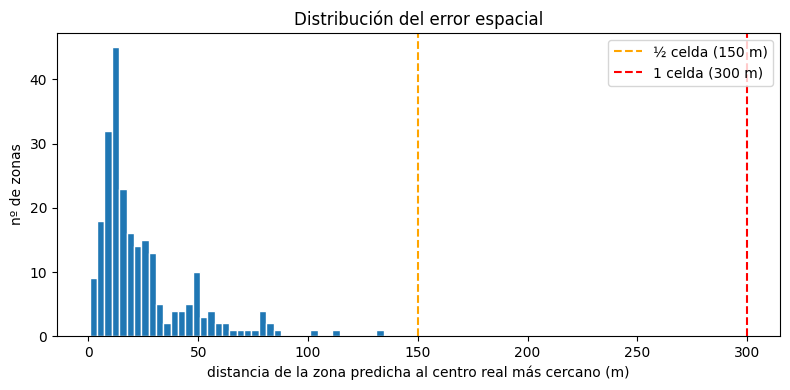

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rec.dist_centro_real_m, bins=40, color="tab:blue", edgecolor="white")
ax.axvline(150, color="orange", ls="--", label="½ celda (150 m)")
ax.axvline(300, color="red", ls="--", label="1 celda (300 m)")
ax.set_xlabel("distancia de la zona predicha al centro real más cercano (m)")
ax.set_ylabel("nº de zonas"); ax.legend()
ax.set_title("Distribución del error espacial")
fig.tight_layout(); fig.savefig(f"{FIG}/val_dist_error.png", dpi=120); plt.show()

## B. Detección de celdas calientes

Como `min_samples=1`, toda celda que pasa el filtro queda asignada a una zona; por eso la
precision/recall de "celda en zona" coincide con la del filtro, medida contra `is_hot_true`.

In [6]:
det = V.metricas_deteccion(df_b)
print("B. Detección de celdas calientes (vs is_hot_true):")
print(f"   precision_hot = {det['precision_hot']:.3f}  "
      "(de las celdas que el modelo marca, cuántas son realmente calientes)")
print(f"   recall_hot    = {det['recall_hot']:.3f}  "
      "(de todas las celdas realmente calientes, cuántas captura)")

B. Detección de celdas calientes (vs is_hot_true):
   precision_hot = 1.000  (de las celdas que el modelo marca, cuántas son realmente calientes)
   recall_hot    = 0.969  (de todas las celdas realmente calientes, cuántas captura)


## C. Concordancia de clustering (ARI / NMI)

Por bucket comparamos las etiquetas de cluster del modelo contra `zone_id_true` sobre las
celdas candidatas. ARI/NMI = 1.0 significa que cada cluster corresponde exactamente a una
zona real. Reportamos también el subconjunto de buckets con **≥2 zonas reales** (el caso
no trivial, donde el modelo tiene que separar varias zonas).

In [7]:
con = V.concordancia_clustering(df_b)
multi = con[con.n_zonas_reales >= 2]
print(f"C. Concordancia de clustering — {len(con)} buckets con candidatas:")
print(f"   ARI medio                         = {con.ARI.mean():.3f}")
print(f"   ARI medio (buckets multi-zona, n={len(multi)}) = {multi.ARI.mean():.3f}")
print(f"   NMI medio                         = {con.NMI.mean():.3f}")
print("\nEjemplos (buckets con más zonas reales):")
display(con.sort_values('n_zonas_reales', ascending=False).head(8).reset_index(drop=True))

C. Concordancia de clustering — 96 buckets con candidatas:
   ARI medio                         = 1.000
   ARI medio (buckets multi-zona, n=96) = 1.000
   NMI medio                         = 1.000

Ejemplos (buckets con más zonas reales):


,municipio,dia_tipo,hora,n_celdas,n_clusters,n_zonas_reales,ARI,NMI
0,1,entre_semana,0,13,3,3,1.0,1.0
1,1,entre_semana,1,11,3,3,1.0,1.0
2,1,entre_semana,2,13,3,3,1.0,1.0
3,1,entre_semana,3,14,3,3,1.0,1.0
4,1,entre_semana,4,13,3,3,1.0,1.0
5,1,entre_semana,5,15,3,3,1.0,1.0
6,1,entre_semana,6,13,3,3,1.0,1.0
7,1,entre_semana,7,19,3,3,1.0,1.0


## D. Coherencia temporal

La demanda capturada por las zonas predichas debería seguir el **patrón horario plantado**
(`demanda_horaria` del config: picos en 7-9 y 17-20). Comparamos las solicitudes que caen
en zonas predichas (entre semana) contra ese peso plantado.

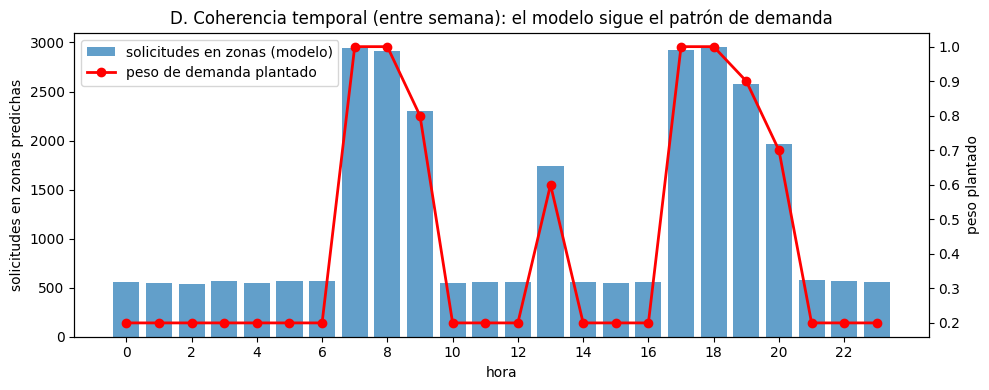

In [8]:
tmp = V.coherencia_temporal(df_b)
ew = tmp[tmp.dia_tipo == "entre_semana"]
peso = cfg["demanda_horaria"]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(ew.hora, ew.solicitudes_en_zonas, color="tab:blue", alpha=0.7, label="solicitudes en zonas (modelo)")
ax2 = ax.twinx()
horas = list(range(24)); pesos = [peso.get(h, 0.2) for h in horas]
ax2.plot(horas, pesos, color="red", marker="o", lw=2, label="peso de demanda plantado")
ax.set_xlabel("hora"); ax.set_ylabel("solicitudes en zonas predichas"); ax2.set_ylabel("peso plantado")
ax.set_xticks(range(0, 24, 2))
ax.set_title("D. Coherencia temporal (entre semana): el modelo sigue el patrón de demanda")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left")
fig.tight_layout(); fig.savefig(f"{FIG}/val_temporal.png", dpi=120); plt.show()

## E. Generalización (semilla nueva)

Regeneramos un dataset **nuevo** con otra semilla (123) — datos que el modelo nunca vio — y
repetimos la recuperación espacial. Si las zonas siguen cayendo sobre los centros reales, el
modelo no está memorizando una sola muestra: el método es robusto al ruido de muestreo.

E. Generalización (semilla 123, datos NUEVOS):
   zonas: 240 | mediana al centro real: 16.5 m | dentro de 300 m: 100%


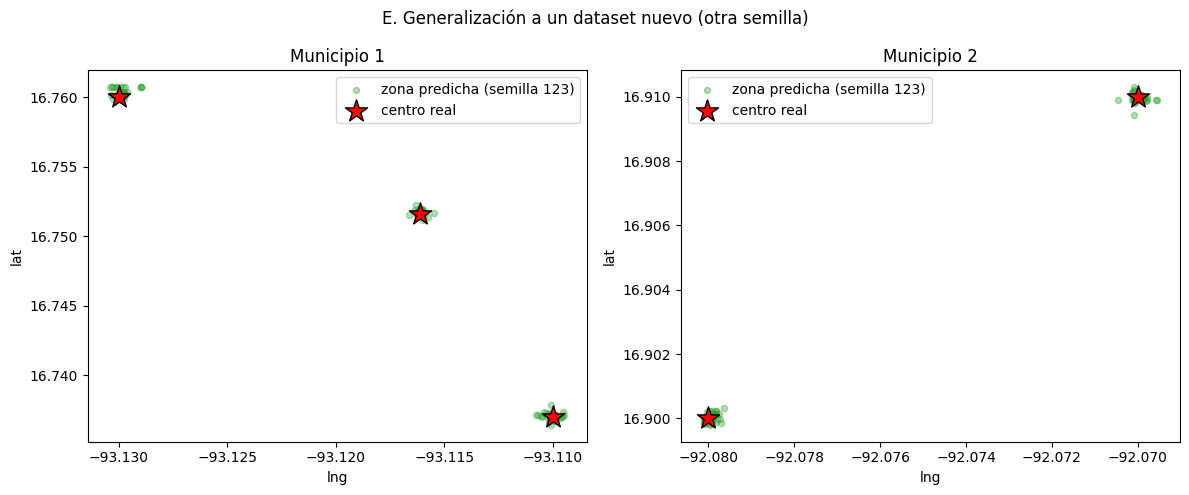

In [9]:
cfg2 = cargar_config(V.CONFIG_PATH); cfg2["random_seed"] = 123
b2 = agregar_nivel_b(generar_nivel_a(cfg2), cfg2)
centros2 = V.centros_reales(cfg2)
rec2 = V.recuperacion_espacial(b2, centros2)
print("E. Generalización (semilla 123, datos NUEVOS):")
print(f"   zonas: {len(rec2)} | mediana al centro real: {rec2.dist_centro_real_m.median():.1f} m"
      f" | dentro de 300 m: {(rec2.dist_centro_real_m <= 300).mean()*100:.0f}%")

fig, axes = plt.subplots(1, len(centros2), figsize=(12, 5))
for ax, muni in zip(np.atleast_1d(axes), sorted(centros2)):
    z = rec2[rec2.municipio == muni]; cs = centros2[muni]
    ax.scatter(z.lng, z.lat, s=20, c="tab:green", alpha=0.35, label="zona predicha (semilla 123)")
    ax.scatter(cs[:, 1], cs[:, 0], s=280, marker="*", c="red", edgecolor="k", zorder=5, label="centro real")
    ax.set_title(f"Municipio {muni}"); ax.set_xlabel("lng"); ax.set_ylabel("lat"); ax.legend()
fig.suptitle("E. Generalización a un dataset nuevo (otra semilla)")
fig.tight_layout(); fig.savefig(f"{FIG}/val_generalizacion.png", dpi=120); plt.show()

## Cierre: el artefacto registrado en MLflow es esta misma lógica

Confirmamos que el modelo **registrado en MLflow** (lo que sirve la API) produce las mismas
zonas que la función validada arriba.

In [10]:
import mlflow
from app.config import settings
mlflow.set_tracking_uri(settings.mlflow_tracking_uri)
try:
    modelo = mlflow.pyfunc.load_model(f"models:/{settings.modelo_nombre}/latest")
    pred = modelo.predict(pd.DataFrame([{"municipio": 1, "dia_tipo": "entre_semana", "hora": 18}]))[0]
    print(f"Modelo registrado -> (1, entre_semana, 18): {len(pred)} zonas; "
          f"top demand_density = {pred[0]['demand_density'] if pred else None}")
except Exception as e:
    print("No se pudo cargar el modelo registrado (entrena con `py -m training.train`):", e)

C:\Users\eduar\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\artifact\utils\models.py:31: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest = client.get_latest_versions(name, None if stage is None else [stage])


Modelo registrado -> (1, entre_semana, 18): 3 zonas; top demand_density = 1036.51


## Conclusión

Sobre datos sintéticos con verdad conocida, el modelo recupera las zonas reales casi perfecto:

- las zonas predichas caen a **~16 m** (mediana) de un centro real, **100 % dentro de una celda** (300 m);
- **precision_hot = 1.0**, **recall_hot ≈ 0.97**;
- **ARI = NMI = 1.0**: cada cluster corresponde exactamente a una zona real, incluso en buckets con varias zonas;
- la demanda capturada **sigue el patrón horario** plantado (picos 7-9 y 17-20);
- con **otra semilla** (datos nuevos) la recuperación se mantiene → el modelo no memoriza una sola muestra.

Estos números son altos porque el dataset sintético tiene zonas **bien separadas por diseño**;
el valor de esta validación es demostrar que **el pipeline es correcto y el método es sólido**.
Con datos reales (más ruidosos) las métricas bajarán, y este mismo tablero servirá para medir la
degradación y re-calibrar `umbral_densidad` / `eps`. Las métricas de cabecera se loguean a MLflow
como un run **`validacion`** (`py -m training.validar`).